In [10]:
import math
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

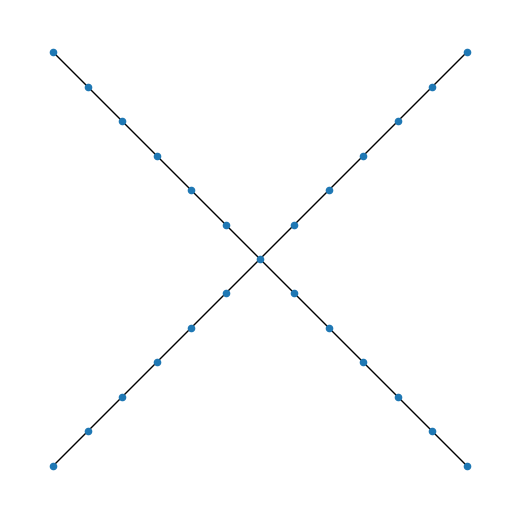

In [9]:
df = pd.read_csv('../data/demo-4.csv')

G = nx.Graph()

# add nodes (remove duplicates)

nodes = df.drop_duplicates(subset='id')

for _, row in df.iterrows():
    G.add_node(
        int(row["id"]),
        road=row["road"],
        pos=(row["lat"], row["lon"]),
    )

# add edges
df["from_id"] = df.groupby("road")["id"].shift(1)
df["to_id"] = df["id"]

edges = df.dropna(subset=["from_id"]).copy()


for _, row in edges.iterrows():
    G.add_edge(
        int(row["from_id"]),
        int(row["to_id"]),
        road=row["road"],
        type=row["model_type"],
        length=row["length"]
    )

pos = nx.get_node_attributes(G, "pos")

plt.figure(figsize=(5,5))
nx.draw(G, pos, node_size=20)
plt.show()

